# OnePen — Feature-Engineering EDA

Exploring the **12 geometric features** used by the stroke classifier: which
carry signal, which are redundant, how classes separate, and what new features
are worth engineering. Companion to the model comparison in `out/comparison.md`.

Classes: `underline, box, curly, delete, squarebracket, wavybracket, circlebracket, none`.

In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')

# import the trainer's data pipeline (1:1 with the app's features)
TRAINER = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, TRAINER)
import data as D

DATA = os.path.join(TRAINER, '..', 'data', 'raw_jsonl')
ds = D.build_dataset(DATA, augment=0, seed=0, log=lambda *a: None)
FEATURES = ['closureRatio','compactness','spreadRatio','aspectRatio','edgeFrac',
            'numPoints','heightDiff','horizVar','totalLen','perimDiagRatio',
            'spineVerticality','vertVar']
df = pd.DataFrame(ds.features, columns=FEATURES)
df['label'] = [D.CLASSES[i] for i in ds.labels]
print(df.shape); df.head()

(4936, 13)


,closureRatio,compactness,spreadRatio,aspectRatio,edgeFrac,numPoints,heightDiff,horizVar,totalLen,perimDiagRatio,spineVerticality,vertVar,label
0,0.836590,2.256443,0.079617,0.467030,0.663158,95.0,1.0000,59.393150,604.724915,2.824635,0.442359,68.992813,box
1,0.800746,2.312427,0.084404,0.465185,0.701754,57.0,0.6762,35.997288,349.705353,2.824199,0.079219,39.098934,box
2,0.769988,2.435138,0.082366,0.521732,0.818182,55.0,0.4098,30.062065,306.746307,2.826779,0.010327,32.041023,box
3,0.804386,2.341789,0.077480,0.464127,0.590909,44.0,0.5126,27.848989,302.250031,2.823938,0.433373,34.565601,box
4,0.741948,2.390325,0.108086,0.603836,0.722222,54.0,0.4752,44.655499,379.401154,2.790888,0.124355,34.654610,box


## 1. Class balance
`delete` and `underline` dominate; `curly` is the rarest. Training uses balanced
class weights to compensate.

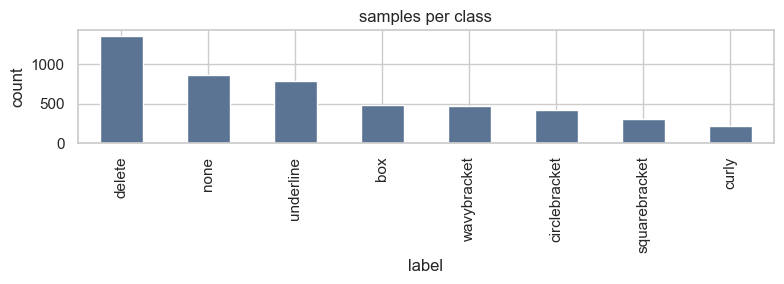

In [2]:
ax = df['label'].value_counts().plot(kind='bar', figsize=(8,3), color='#5b7493')
ax.set_title('samples per class'); ax.set_ylabel('count'); plt.tight_layout()

## 2. Feature importance
Two independent rankings — **mutual information** (model-free) and **RandomForest**
impurity importance. `compactness` and `closureRatio` dominate: they cleanly
separate closed shapes (box/circle) from open ones (underline/bracket).

,mutual_info,rf_importance
compactness,0.939,0.204
closureRatio,0.826,0.141
spreadRatio,0.611,0.094
edgeFrac,0.392,0.093
numPoints,0.449,0.072
vertVar,0.577,0.068
aspectRatio,0.573,0.064
perimDiagRatio,0.424,0.063
horizVar,0.468,0.055
totalLen,0.429,0.051


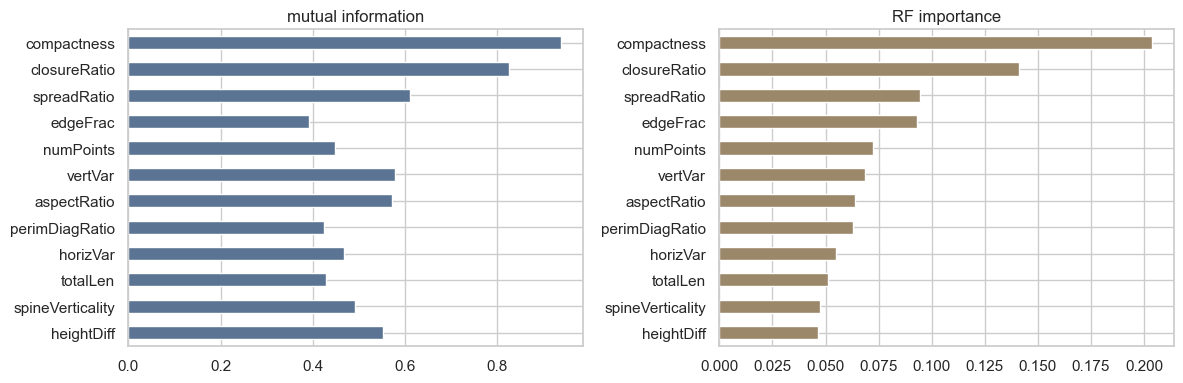

In [3]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
X, y = ds.features, ds.labels
mi = mutual_info_classif(X, y, random_state=0)
rf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1).fit(X, y)
imp = pd.DataFrame({'mutual_info': mi, 'rf_importance': rf.feature_importances_}, index=FEATURES)
imp = imp.sort_values('rf_importance', ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
imp['mutual_info'].plot.barh(ax=ax[0], color='#5b7493', title='mutual information'); ax[0].invert_yaxis()
imp['rf_importance'].plot.barh(ax=ax[1], color='#9b8769', title='RF importance'); ax[1].invert_yaxis()
plt.tight_layout(); imp.round(3)

## 3. Redundancy — correlation heatmap
No pair exceeds |r| = 0.85, so all 12 features add non-overlapping information —
there is nothing obvious to drop.

redundant pairs (|r|>0.85): none


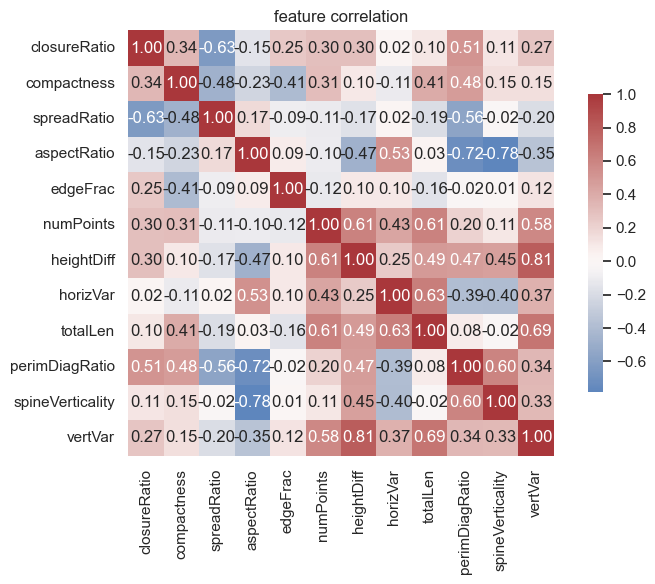

In [4]:
corr = df[FEATURES].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, square=True, cbar_kws={'shrink':.7})
plt.title('feature correlation'); plt.tight_layout()
hi = [(FEATURES[i], FEATURES[j], round(corr.iloc[i,j],2))
      for i in range(12) for j in range(i+1,12) if abs(corr.iloc[i,j])>0.85]
print('redundant pairs (|r|>0.85):', hi or 'none')

## 4. Per-class feature signatures
Z-scored mean of each feature per class — the 'fingerprint' the model keys on.
e.g. `box`/`circlebracket` light up on `closureRatio`; `underline` on
`spineVerticality`(low) + `aspectRatio`; `delete` on path complexity.

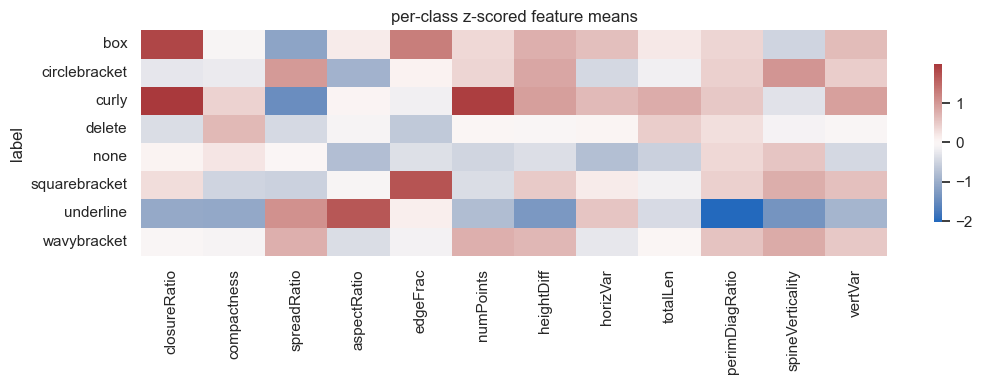

In [5]:
z = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std()
z['label'] = df['label']
sig = z.groupby('label')[FEATURES].mean()
plt.figure(figsize=(11,4))
sns.heatmap(sig, annot=False, cmap='vlag', center=0, cbar_kws={'shrink':.7})
plt.title('per-class z-scored feature means'); plt.tight_layout()

## 5. Class separability (PCA)
12-D features projected to 2-D. Tight, well-separated clusters mean the features
alone already carry most of the signal (confirmed by the RF ceiling below).

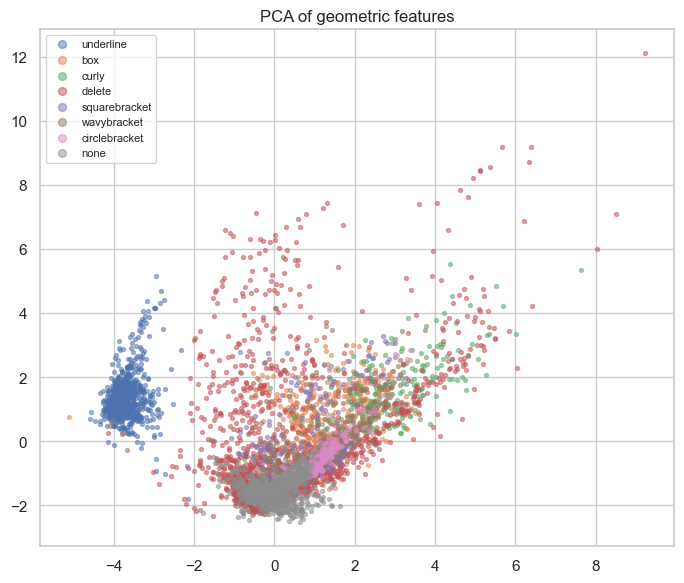

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
Z = StandardScaler().fit_transform(X)
pc = PCA(n_components=2, random_state=0).fit_transform(Z)
plt.figure(figsize=(7,6))
for c in D.CLASSES:
    m = df['label'].values == c
    plt.scatter(pc[m,0], pc[m,1], s=8, alpha=0.5, label=c)
plt.legend(markerscale=2, fontsize=8); plt.title('PCA of geometric features'); plt.tight_layout()

## 6. Top features by class
Distribution of the two strongest features across classes.

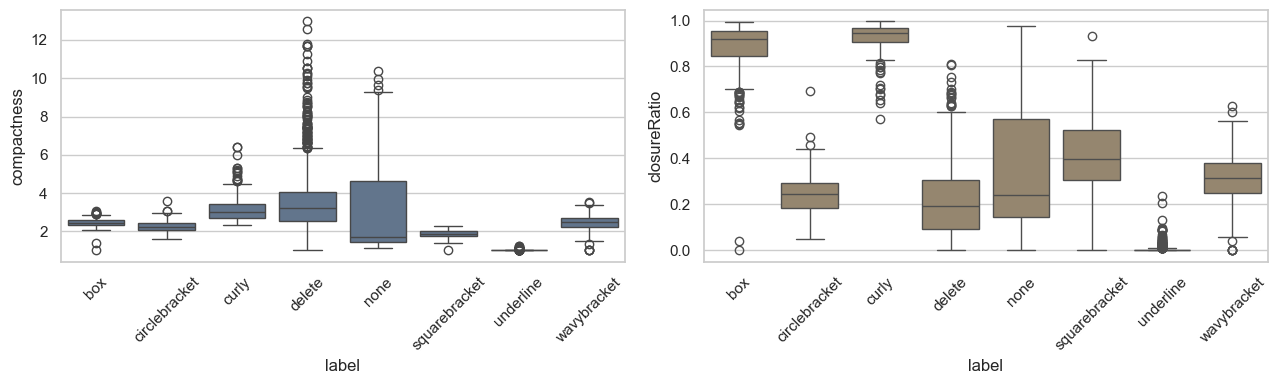

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
order = sorted(D.CLASSES)
sns.boxplot(data=df, x='label', y='compactness', order=order, ax=ax[0], color='#5b7493')
sns.boxplot(data=df, x='label', y='closureRatio', order=order, ax=ax[1], color='#9b8769')
for a in ax: a.tick_params(axis='x', rotation=45)
plt.tight_layout()

## 7. Geometric ceiling
How far the 12 features get *on their own* with a strong classical model — the
bar the neural nets must beat.

In [8]:
from sklearn.model_selection import cross_val_score
acc = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1),
                      X, y, cv=5).mean()
print(f'RandomForest 5-fold accuracy on the 12 features: {acc:.3f}')

RandomForest 5-fold accuracy on the 12 features: 0.895


## 8. Findings & feature-engineering recommendations

**What the data says**
- The 12 features are **non-redundant** (no |r| > 0.85) — keep them all.
- `compactness`, `closureRatio`, `spreadRatio` carry the most signal (closed vs
  open vs spread-out shapes).
- A RandomForest on features alone reaches **~0.90** — the hand-crafted features
  are remarkably strong, which is why `geometric` and `tcn_hybrid` train so fast.

**Highest-ROI new features to try** (each targets a confusable pair):
- **total curvature** Σ|Δθ| and **direction-reversal count** → `curly`/`wavybracket`
  vs straight `underline`/`squarebracket`.
- **corner count** (high-curvature points) → `box` (≈4 corners) vs brackets.
- **convex-hull area ratio** (stroke area / hull area) → closed `box`/`circlebracket`
  vs open shapes.
- **self-intersection count** → `delete` (X / scribble) vs everything else.
- **endpoint geometry** (start/end y, gap direction) → bracket orientation.

**Recommendation**
- For the **sequence model (TCN)** these are learned implicitly — it already wins,
  so no manual features are needed there.
- For the deployed **hybrid**, adding *total curvature* + *corner count* is the
  cheapest accuracy lift (both are O(n) over the stroke and parity-portable to
  `features.ts`). Bump `FEATURE_DIM` and retrain to compare.

_Re-run this notebook after editing `data.py:compute_features` to see the effect._